<a href="https://colab.research.google.com/github/Wai-Fun/Healthcare-Data-Analytics/blob/main/Unsupervised_Learning_K_means_%26_Hierarchical_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Unsupervised Learning: K-means & Hierarchical Clustering for Patient Phenotype Discovery

## Overview
In real-world healthcare settings, clinicians often observe that not all patients
with the same diagnosis behave or respond to care in the same way.
Clustering allows **discovering natural groupings of patients** based on their
clinical characteristics, without telling the algorithm what to look for in advance. These groups, often called *phenotypes*, can support population health management,
care pathway design, and hypothesis generation.


## Objectives
- Prepare clinical features for unsupervised learning.
- Apply clustering to discover patient subgroups.
- Examine and describe patient clusters.
- Interpret the clusters as potential clinical phenotypes.

##The Dataset

This is a synthetic, de-identified patient-level dataset
that represents information typically available after data cleaning and feature
engineering. Each row represents a patient, and each column represents a clinical
characteristic such as lab results or healthcare utilization.



##0. Setup

In [37]:
# Import pandas for working with tables of data
import pandas as pd

# Import tools for scaling data and clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load a patient-level feature dataset
# Each row represents a patient
# Each column represents a clinical feature
patient_features = pd.read_csv("https://machine-learning-for-healthcare-applications-f276df.gitlab.io/labs/lab2/patient_features1.csv")

##1. EDA

In [38]:
#Dataset structure
patient_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   avg_glucose       2000 non-null   float64
 1   encounter_count   2000 non-null   int64  
 2   has_diabetes      2000 non-null   int64  
 3   has_hypertension  2000 non-null   int64  
dtypes: float64(1), int64(3)
memory usage: 62.6 KB


In [39]:
#Statistic summary
patient_features.describe()

,avg_glucose,encounter_count,has_diabetes,has_hypertension
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,126.126000,3.019500,0.433500,0.418000
std,24.711498,1.417436,0.495682,0.493354
min,44.000000,1.000000,0.000000,0.000000
25%,109.400000,2.000000,0.000000,0.000000
50%,126.100000,3.000000,0.000000,0.000000
75%,142.050000,4.000000,1.000000,1.000000
max,221.300000,5.000000,1.000000,1.000000


In [40]:
#Missing Value
patient_features.isnull().sum()

,0
avg_glucose,0
encounter_count,0
has_diabetes,0
has_hypertension,0


In [41]:
#Duplicate rows
patient_features.duplicated().sum()


np.int64(112)

In [42]:
#Drop duplicate rows
patient_features.drop_duplicates(inplace=True)

In [43]:
patient_features.duplicated().sum()

np.int64(0)

##2. Feature scaling

In [44]:
# Create a scaler that standardizes features
scaler = StandardScaler()

# Fit the scaler to the data and transform it
scaled_features = scaler.fit_transform(patient_features)

# Display the scaled feature values
scaled_features


array([[ 0.44968394, -0.01714472, -0.88381677,  1.16999287],
       [-0.18398387, -0.01714472, -0.88381677, -0.85470606],
       [ 0.60112656, -0.01714472,  1.13145625, -0.85470606],
       ...,
       [-0.92127032, -1.42450233, -0.88381677, -0.85470606],
       [-0.20789586, -1.42450233, -0.88381677,  1.16999287],
       [-0.78576903,  0.68653409,  1.13145625, -0.85470606]])

##3. Clustering by K-means

In [45]:
# Create a k-means clustering model
kmeans = KMeans(n_clusters=2, random_state=42) # n_clusters defines how many patient groups you want to discover

# Fit the model and assign each patient to a cluster
clusters = kmeans.fit_predict(scaled_features)


In [46]:
# Add cluster labels as a new column in the dataset (optional)
patient_features["cluster"] = clusters

# Display patient data with cluster labels (optional)
patient_features.head(5)

,avg_glucose,encounter_count,has_diabetes,has_hypertension,cluster
0,137.4,3,0,1,0
1,121.5,3,0,0,1
2,141.2,3,1,0,1
3,163.1,4,1,0,1
4,119.1,5,0,0,1


##3.1 Cluster Characteristic

In [47]:
patient_features['cluster'].value_counts()

,count
cluster,
1,1091
0,797


In [48]:
#Identify High-Utilization Cluster
patient_features.groupby("cluster")['encounter_count'].mean()

,encounter_count
cluster,
0,3.015056
1,3.031164


In [49]:
# Group patients by cluster and compute average values
cluster_summary = patient_features.groupby("cluster").mean()

# Display the cluster-level summaries
cluster_summary

,avg_glucose,encounter_count,has_diabetes,has_hypertension
cluster,,,,
0,126.920326,3.015056,0.429109,1.0
1,125.529331,3.031164,0.445463,0.0


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


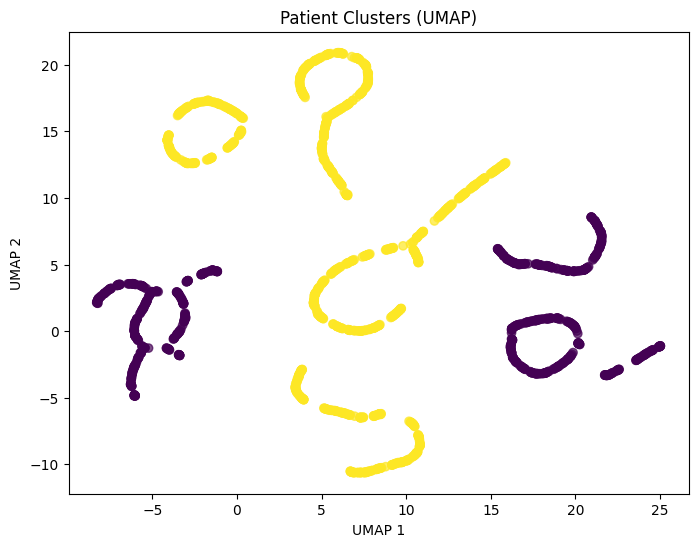

In [50]:
#Visualize the cluster
import umap.umap_ as umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(
    n_components=2,
    random_state=42
)

reduced = reducer.fit_transform(scaled_features)

plt.figure(figsize=(8,6))
plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=clusters,
    alpha=0.7
)

plt.title("Patient Clusters (UMAP)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

In [51]:
# Cluster Evaluation - Silhouette Score
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_features, clusters)

print(f"Silhouette Score: {score:.3f}")

# Interpretation of the score
if score > 0.70:
    SilhouetteScoreInterpretation = "Excellent cluster separation (very well-defined patient groups)."
elif score > 0.50:
    SilhouetteScoreInterpretation = "Good cluster structure (reasonably distinct patient groups)."
elif score > 0.25:
    SilhouetteScoreInterpretation = "Weak cluster structure (some overlap between patient groups)."
else:
    SilhouetteScoreInterpretation = "Poor cluster separation (clusters are not well-defined)."

print("Interpretation:", SilhouetteScoreInterpretation)

Silhouette Score: 0.272
Interpretation: Weak cluster structure (some overlap between patient groups).


In [52]:
# Evaluate Different number of cluster, n_cluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 8):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(scaled_features)

    sil = silhouette_score(scaled_features, labels)

    results.append([k, sil])

results_df = pd.DataFrame(results,
                          columns=["k", "silhouette_score"])

print(results_df)

   k  silhouette_score
0  2          0.271674
1  3          0.284852
2  4          0.311977
3  5          0.279877
4  6          0.325021
5  7          0.322265


The best result is k = 4 with a silhouette score of 0.36, meaning it gives the most meaningful clustering among the tested values.

However, all scores are relatively low (0.27–0.36), which suggests weak separation between patient groups. This means the clusters overlap and the patient “phenotypes” are not strongly distinct.

Overall, there is some structure in the data, but it is not very strong or clearly separated.

##4. Clustering by Hierarchical

In [53]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=4)
hc_clusters = hc.fit_predict(scaled_features)


In [54]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 9):  # k = 2 to 8
    hc = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    hc_clusters = hc.fit_predict(scaled_features)

    sil_score = silhouette_score(
        scaled_features,
        hc_clusters
    )

    results.append([k, sil_score])

# Create results table
hc_results = pd.DataFrame(
    results,
    columns=["k", "silhouette_score"]
)

print(hc_results)

   k  silhouette_score
0  2          0.271674
1  3          0.288091
2  4          0.359228
3  5          0.329542
4  6          0.331859
5  7          0.344523
6  8          0.352752


The silhouette score for hierarchical clustering for k=2 to 8 is very similar to k-means clustering. all scores are relatively low (0.27–0.36), which suggests weak separation between patient groups.

##5. Conclusion:
K-means and Hierarchical Clustering were used to group patients with similar characteristics. Both methods produced similar results, with the best clustering found at k = 4.

However, the silhouette scores were relatively low (about 0.27–0.36), indicating that the patient groups are not clearly separated and tend to overlap. This suggests that some clustering structure exists in the data, but the patient phenotypes are not strongly distinct.

Disclaimer: This project was completed as part of the coursework for Machine Learning for Healthcare Applications. The dataset used in this analysis is synthetic and de-identified. Additional steps were included to enhance understanding and improve the completeness of the project.